In [ ]:
# %%
# STEP 1 — IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Optional for spatial autocorrelation
#pip3 install esda libpysal geopandas shapely
import geopandas as gpd
from libpysal.weights import DistanceBand
from esda.moran import Moran

In [5]:
# %%
# STEP 2 — LOAD DATA
csv_path = '/Users/jakegehrung/Desktop/data_raw/data_processed/fintry_epc_processed.csv'
df = pd.read_csv(csv_path)

# Quick check
print(df.columns)
print(f"Number of houses: {len(df)}")

# Focus on relevant columns
df_sub = df[['LATITUDE', 'LONGITUDE', 'ENERGY_CONSUMPTION_CURRENT']].dropna()
print(f"Number of houses with energy consumption: {len(df_sub)}")

Index(['BUILDING_REFERENCE_NUMBER', 'OSG_REFERENCE_NUMBER', 'ADDRESS1',
       'ADDRESS2', 'ADDRESS3', 'POSTCODE', 'LATITUDE', 'LONGITUDE',
       'INSPECTION_DATE', 'TYPE_OF_ASSESSMENT',
       ...
       'WALL_DESCRIPTION_PARSED', 'ROOF_DESCRIPTION_PARSED',
       'FLOOR_DESCRIPTION_PARSED', 'WINDOWS_DESCRIPTION_PARSED',
       'MAINHEAT_DESCRIPTION_PARSED', 'MAINHEATCONT_DESCRIPTION_PARSED',
       'SECONDHEAT_DESCRIPTION_PARSED', 'HOTWATER_DESCRIPTION_PARSED',
       'LIGHTING_DESCRIPTION_PARSED', 'AIR_TIGHTNESS_DESCRIPTION_PARSED'],
      dtype='object', length=120)
Number of houses: 117
Number of houses with energy consumption: 117


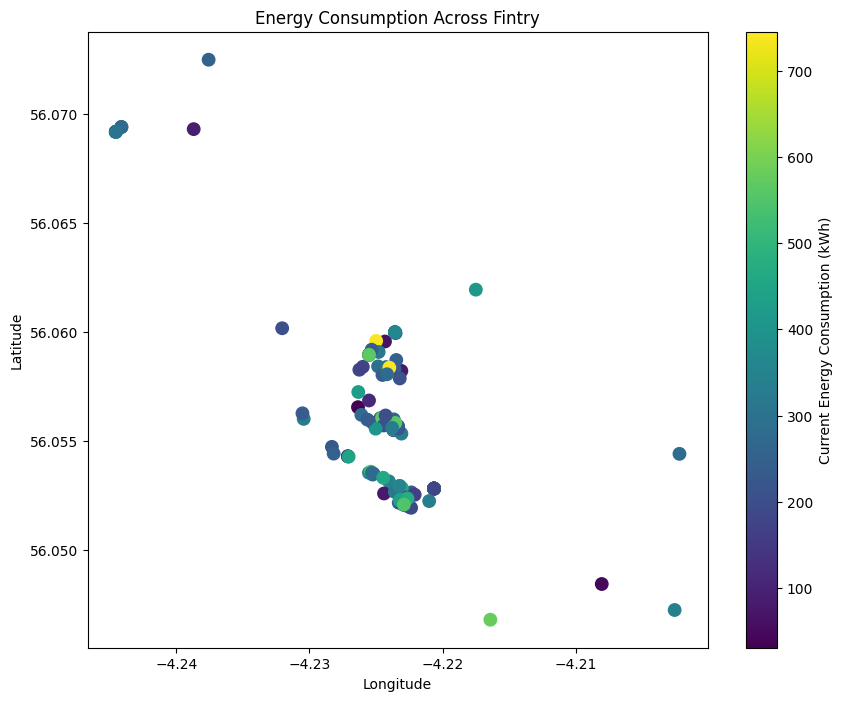

In [ ]:
# %%
# STEP 3 — EXPLORATORY VISUALIZATION
plt.figure(figsize=(10, 8))
sc = plt.scatter(df_sub['LONGITUDE'], df_sub['LATITUDE'], 
                 c=df_sub['ENERGY_CONSUMPTION_CURRENT'], cmap='viridis', s=80)
plt.colorbar(sc, label='Current Energy Consumption (kWh/m²/year)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Energy Consumption Across Fintry')
plt.show()

In [7]:
# %%
# STEP 4 — CORRELATION BETWEEN LOCATION AND ENERGY CONSUMPTION
# Pearson correlation between latitude/longitude and energy consumption
lat_corr, lat_p = pearsonr(df_sub['LATITUDE'], df_sub['ENERGY_CONSUMPTION_CURRENT'])
lon_corr, lon_p = pearsonr(df_sub['LONGITUDE'], df_sub['ENERGY_CONSUMPTION_CURRENT'])

print(f"Correlation with Latitude: {lat_corr:.3f} (p={lat_p:.3f})")
print(f"Correlation with Longitude: {lon_corr:.3f} (p={lon_p:.3f})")

Correlation with Latitude: 0.032 (p=0.732)
Correlation with Longitude: -0.033 (p=0.728)


In [8]:
# %%
# STEP 5 — SPATIAL AUTOCORRELATION (Moran's I)
# Convert to GeoDataFrame
gdf = gpd.GeoDataFrame(df_sub, geometry=gpd.points_from_xy(df_sub['LONGITUDE'], df_sub['LATITUDE']))

# Create distance-based weights (neighbors within 200 meters)
w = DistanceBand.from_dataframe(gdf, threshold=0.2, binary=True, silence_warnings=True)

# Moran's I for energy consumption
moran = Moran(gdf['ENERGY_CONSUMPTION_CURRENT'], w)
print(f"Moran's I: {moran.I:.3f}, p-value: {moran.p_sim:.3f}")

Moran's I: -0.009, p-value: 0.288


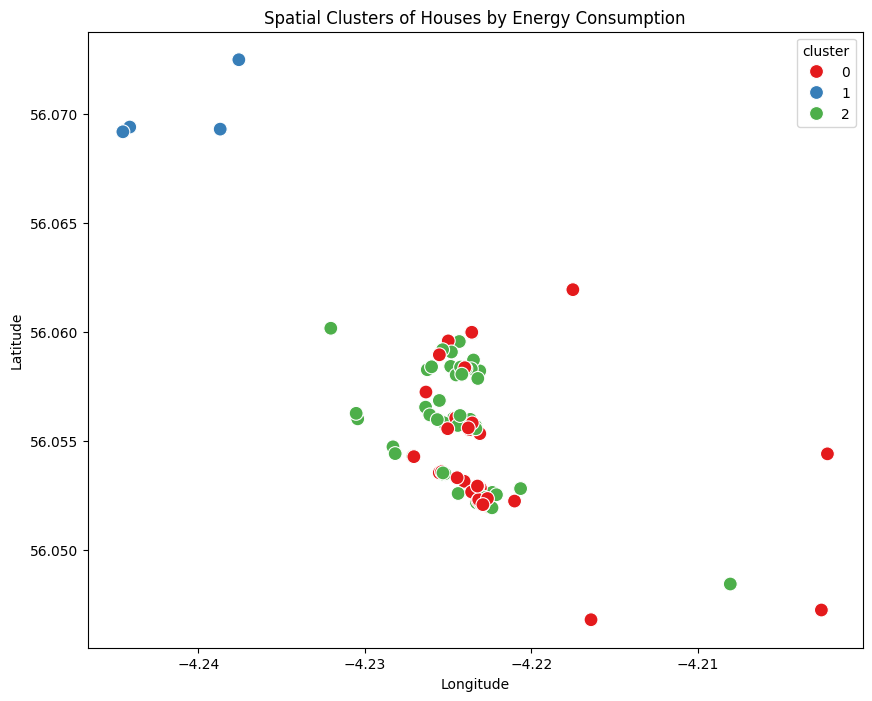

In [9]:
# %%
# STEP 6 — CLUSTERING HOUSES BY LOCATION AND ENERGY
# Standardize features
X = df_sub[['LATITUDE', 'LONGITUDE', 'ENERGY_CONSUMPTION_CURRENT']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# KMeans clustering (try 3 clusters as example)
kmeans = KMeans(n_clusters=3, random_state=42)
df_sub['cluster'] = kmeans.fit_predict(X_scaled)

# Visualize clusters
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df_sub, x='LONGITUDE', y='LATITUDE', hue='cluster', palette='Set1', s=100)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Spatial Clusters of Houses by Energy Consumption')
plt.show()

In [10]:
# %%
# STEP 7 — SUMMARY STATISTICS BY CLUSTER
cluster_summary = df_sub.groupby('cluster')['ENERGY_CONSUMPTION_CURRENT'].agg(['count','mean','std','min','max'])
print(cluster_summary)

         count        mean         std  min  max
cluster                                         
0           41  447.414634  111.262073  284  745
1           12  303.250000  105.953785   92  538
2           64  198.359375   73.528607   31  326




## **1. Exploratory Visualization**

* The scatter plot of energy consumption across the village shows **no obvious spatial pattern**. Houses with higher or lower energy use per unit area appear distributed across the area.
* This is consistent with the subsequent correlation and spatial tests.

---

## **2. Correlation Between Location and Energy Consumption**

* **Latitude correlation:** 0.032 (p = 0.732)
* **Longitude correlation:** -0.033 (p = 0.728)

**Interpretation:**

* The correlations are **extremely low** and **not statistically significant** (p > 0.05).
* This indicates that **simply being in a certain part of the village does not predict a house’s energy consumption per square meter**.
* There is no linear relationship between coordinates and energy use intensity.

---

## **3. Spatial Autocorrelation (Moran’s I)**

* Moran’s I: -0.009, p-value = 0.288

**Interpretation:**

* Moran’s I near zero indicates **no spatial autocorrelation**.
* Energy consumption per m² is **not clustered spatially** at the scale of the village — nearby houses do not consistently have similar energy use intensity.
* Statistically, location alone is **not sufficient for archetyping**.

---

## **4. Clustering by Location and Energy Consumption**

* KMeans clustering with **3 clusters** produced:

| Cluster | Count | Mean Energy (kWh/m²/year) | Std Dev | Min | Max |
| ------- | ----- | ------------------------- | ------- | --- | --- |
| 0       | 41    | 447                       | 111     | 284 | 745 |
| 1       | 12    | 303                       | 106     | 92  | 538 |
| 2       | 64    | 198                       | 74      | 31  | 326 |

**Interpretation:**

* Clustering **mainly separated houses by energy consumption intensity**, not by location.
* Cluster 0 contains the **highest energy users per m²**, cluster 2 the **lowest**, cluster 1 intermediate.
* On the map, clusters are **scattered across the village**, reinforcing that location is **not the main driver** of energy differences.

---

## **5. Should a Larger Number of Groups Be Used?**

* With only 117 houses, increasing KMeans clusters significantly may **overfit** — small clusters might contain very few houses, making statistical inference unreliable.
* Since **spatial correlation is negligible**, additional clusters are unlikely to reveal meaningful location-based archetypes.
* **Recommendation:**

  * Keep a small number of clusters (3–4) if you want to segment by energy consumption per m².
  * Archetypes should likely be defined using **building characteristics** (e.g., floor area, age band, construction type) rather than location.

---

## **6. Statistical Takeaways**

1. **Location (latitude/longitude) is not predictive** of energy consumption per unit area (Pearson correlation ≈ 0).
2. **No spatial clustering exists** (Moran’s I ≈ 0).
3. **Energy archetypes are better defined by building properties**, not village location.
4. Clustering by energy use intensity can still identify **high, medium, and low energy houses**, but the clusters are **geographically scattered**.

---

### ✅ **Conclusion**

* For your dataset, **location alone cannot be used to archetype houses**.
* If your goal is to model or forecast energy consumption for unmeasured houses, focus on **building attributes (floor area, construction age, wall/roof types, heating system)**.
* Use energy consumption clustering to identify **typical high/medium/low energy use homes per m²**, but don’t expect these to align spatially within the village.

